# Data Science Internship – February 2026
## NLP Task 2 – Sentiment Analysis using NLP Pipeline & ML Models
**Author:** Neeraj

This project builds an end-to-end sentiment analysis system using NLP preprocessing and multiple machine learning models.

**Overall Flow:**
```
Raw Data → Preprocessing → Feature Engineering → Model Training → Evaluation → Comparison
```

---
## Step 0 – Install & Import Libraries

In [11]:
!pip install pandas numpy nltk scikit-learn matplotlib seaborn --quiet

In [12]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize

# ML
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

# Download required NLTK data
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')

print("✅ All libraries imported successfully!")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...


✅ All libraries imported successfully!


[nltk_data]   Package omw-1.4 is already up-to-date!


---
## Step 1 – Data Loading & Understanding

We use the **IMDb Movie Reviews Dataset** — a classic benchmark for binary sentiment classification (Positive / Negative). It contains 50,000 reviews, balanced across both classes.

> **Source:** The dataset is loaded directly via a public URL (no Kaggle login required for this version). This is equivalent to the Kaggle IMDb dataset.

In [13]:
import urllib.request

url = "https://raw.githubusercontent.com/Ankit152/IMDB-sentiment-analysis/master/IMDB-Dataset.csv"
urllib.request.urlretrieve(url, "IMDB_Dataset.csv")
print("Downloaded successfully!")

Downloaded successfully!


In [14]:
# ---------------------------------------------------------------
# Load the IMDb dataset from a public GitHub mirror
# (Same data as Kaggle's 'IMDb Dataset of 50K Movie Reviews')
# ---------------------------------------------------------------

df = pd.read_csv("IMDB_Dataset.csv")  
print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
df.head()

Dataset loaded successfully!
Shape: (50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [15]:
# Preview first few rows
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [16]:
# --- Basic Dataset Info ---
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"Total Samples   : {len(df)}")
print(f"Columns         : {list(df.columns)}")
print(f"Missing Values  :\n{df.isnull().sum()}")
print()

# Class distribution
print("Class Distribution:")
print(df['sentiment'].value_counts())
print()
print(f"Class Balance   : {df['sentiment'].value_counts(normalize=True).round(3).to_dict()}")

DATASET OVERVIEW
Total Samples   : 50000
Columns         : ['review', 'sentiment']
Missing Values  :
review       0
sentiment    0
dtype: int64

Class Distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Class Balance   : {'positive': 0.5, 'negative': 0.5}


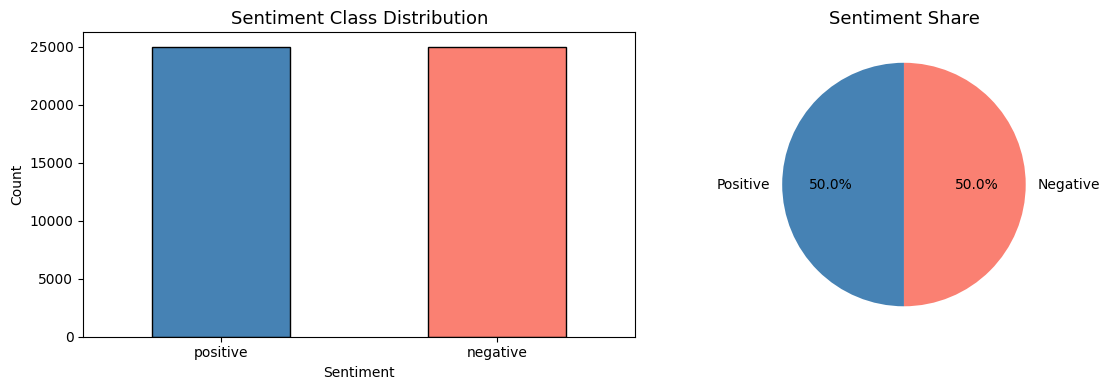

In [17]:
# --- Visualize class distribution ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
df['sentiment'].value_counts().plot(kind='bar', ax=axes[0],
    color=['steelblue', 'salmon'], edgecolor='black')
axes[0].set_title('Sentiment Class Distribution', fontsize=13)
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Pie chart
df['sentiment'].value_counts().plot(kind='pie', ax=axes[1],
    autopct='%1.1f%%', colors=['steelblue', 'salmon'],
    startangle=90, labels=['Positive', 'Negative'])
axes[1].set_title('Sentiment Share', fontsize=13)
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [18]:
# Sample texts from each class
print("--- Sample POSITIVE Review ---")
print(df[df['sentiment']=='positive']['review'].iloc[0][:300], "...\n")

print("--- Sample NEGATIVE Review ---")
print(df[df['sentiment']=='negative']['review'].iloc[0][:300], "...")

--- Sample POSITIVE Review ---
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Tru ...

--- Sample NEGATIVE Review ---
Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />This movie is slower than a soap opera... and suddenly, Jake decides to become Rambo and kill the zombie.<br /><br />OK, first of all when you're going to ma ...


Review Length Statistics (word count):
             count   mean    std   min    25%    50%    75%     max
sentiment                                                          
negative   25000.0  229.5  164.9   4.0  128.0  174.0  278.0  1522.0
positive   25000.0  232.8  177.5  10.0  125.0  172.0  284.0  2470.0


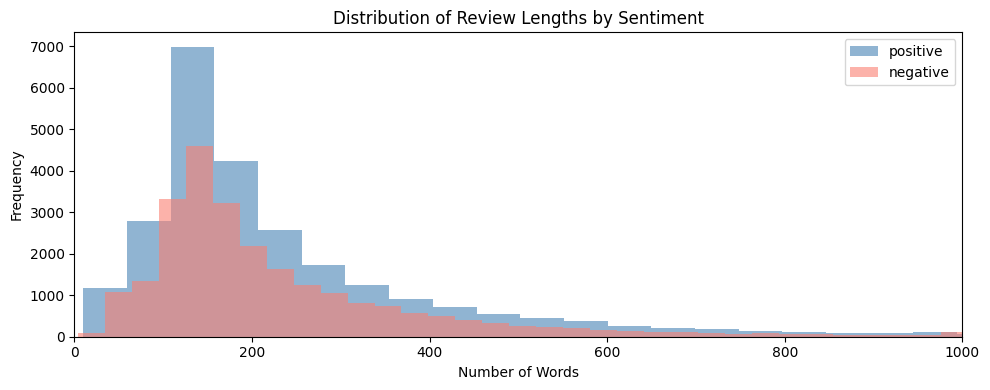

In [19]:
# Review length analysis
df['review_length'] = df['review'].apply(lambda x: len(x.split()))

print("Review Length Statistics (word count):")
print(df.groupby('sentiment')['review_length'].describe().round(1))

# Plot distribution
plt.figure(figsize=(10, 4))
for label, color in [('positive', 'steelblue'), ('negative', 'salmon')]:
    subset = df[df['sentiment'] == label]['review_length']
    plt.hist(subset, bins=50, alpha=0.6, color=color, label=label)
plt.title('Distribution of Review Lengths by Sentiment')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.legend()
plt.xlim(0, 1000)
plt.tight_layout()
plt.show()

---
## Step 2 – NLP Preprocessing

We define a **reusable preprocessing pipeline** that applies the following steps in order:

| Step | Purpose |
|------|---------|
| Lowercasing | Normalize text case |
| Remove HTML tags | Strip `<br />` artifacts in IMDb data |
| Remove URLs | Remove web links |
| Remove special chars / punctuation | Keep only alphabetic tokens |
| Tokenization | Split into individual words |
| Remove stopwords | Drop common non-informative words |
| Stemming / Lemmatization | Reduce words to base form |

In [20]:
# Initialize tools
stop_words = set(stopwords.words('english'))
stemmer    = PorterStemmer()
lemmatizer = WordNetLemmatizer()

# ---------------------------------------------------------------
# Reusable preprocessing function
# use_stemming=True  → apply PorterStemmer
# use_stemming=False → apply WordNetLemmatizer
# ---------------------------------------------------------------
def preprocess_text(text, use_stemming=True):
    """
    Full NLP preprocessing pipeline:
    1. Lowercase
    2. Remove HTML tags
    3. Remove URLs
    4. Remove punctuation & special characters
    5. Tokenize
    6. Remove stopwords
    7. Stem OR Lemmatize
    Returns a single cleaned string.
    """
    # 1. Lowercase
    text = text.lower()

    # 2. Remove HTML tags (e.g., <br />)
    text = re.sub(r'<.*?>', ' ', text)

    # 3. Remove URLs
    text = re.sub(r'http\S+|www\.\S+', ' ', text)

    # 4. Remove everything except lowercase letters and spaces
    text = re.sub(r'[^a-z\s]', ' ', text)

    # 5. Tokenize (split on whitespace)
    tokens = text.split()

    # 6. Remove stopwords and single-character tokens
    tokens = [t for t in tokens if t not in stop_words and len(t) > 1]

    # 7. Stemming or Lemmatization
    if use_stemming:
        tokens = [stemmer.stem(t) for t in tokens]
    else:
        tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return ' '.join(tokens)

print("Preprocessing function defined.")

# --- Quick demo ---
sample = "This movie was ABSOLUTELY brilliant! <br /> Visit https://imdb.com for more info. Loved it!!!"
print("\nOriginal  :", sample)
print("Stemmed   :", preprocess_text(sample, use_stemming=True))
print("Lemmatized:", preprocess_text(sample, use_stemming=False))

Preprocessing function defined.

Original  : This movie was ABSOLUTELY brilliant! <br /> Visit https://imdb.com for more info. Loved it!!!
Stemmed   : movi absolut brilliant visit info love
Lemmatized: movie absolutely brilliant visit info loved


In [21]:
# ---------------------------------------------------------------
# Apply preprocessing to the full dataset
# We keep both stemmed & lemmatized versions for comparison
# Using a sample of 10,000 rows for speed (change to full if needed)
# ---------------------------------------------------------------
SAMPLE_SIZE = 10000   # ← increase to 50000 for full dataset
df_sample = df.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)

print(f"Processing {SAMPLE_SIZE} reviews...")

df_sample['clean_stem']  = df_sample['review'].apply(lambda x: preprocess_text(x, use_stemming=True))
df_sample['clean_lemma'] = df_sample['review'].apply(lambda x: preprocess_text(x, use_stemming=False))

print("✅ Preprocessing complete!")
df_sample[['review', 'clean_stem', 'clean_lemma', 'sentiment']].head(3)

Processing 10000 reviews...
✅ Preprocessing complete!


,review,clean_stem,clean_lemma,sentiment
0,I really liked this Summerslam due to the look...,realli like summerslam due look arena curtain ...,really liked summerslam due look arena curtain...,positive
1,Not many television shows appeal to quite as m...,mani televis show appeal quit mani differ kind...,many television show appeal quite many differe...,positive
2,The film quickly gets to a major chase scene w...,film quickli get major chase scene ever increa...,film quickly get major chase scene ever increa...,negative


In [22]:
# Compare lengths before and after preprocessing
df_sample['len_before'] = df_sample['review'].apply(lambda x: len(x.split()))
df_sample['len_after']  = df_sample['clean_stem'].apply(lambda x: len(x.split()))

print(f"Average word count BEFORE preprocessing : {df_sample['len_before'].mean():.1f}")
print(f"Average word count AFTER  preprocessing : {df_sample['len_after'].mean():.1f}")
print(f"Word reduction: {(1 - df_sample['len_after'].mean()/df_sample['len_before'].mean())*100:.1f}%")

Average word count BEFORE preprocessing : 231.8
Average word count AFTER  preprocessing : 118.2
Word reduction: 49.0%


---
## Step 3 – Feature Engineering

We convert cleaned text into numerical feature matrices using:
- **Bag of Words (BoW)** – word occurrence counts
- **TF-IDF** – term frequency weighted by inverse document frequency

Both will be evaluated with each ML model.

In [23]:
# Encode labels: positive=1, negative=0
df_sample['label'] = df_sample['sentiment'].map({'positive': 1, 'negative': 0})

# Use lemmatized text as the primary cleaned column
X_text = df_sample['clean_lemma']
y      = df_sample['label']

# Train-test split (80/20)
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples : {len(X_train_text)}")
print(f"Test samples     : {len(X_test_text)}")

Training samples : 8000
Test samples     : 2000


In [24]:
# ---------------------------------------------------------------
# Bag of Words (BoW)
# max_features limits vocabulary size to top 10,000 words
# ---------------------------------------------------------------
bow_vectorizer = CountVectorizer(max_features=10000, ngram_range=(1, 2))
X_train_bow = bow_vectorizer.fit_transform(X_train_text)
X_test_bow  = bow_vectorizer.transform(X_test_text)

print(f"BoW Feature Matrix Shape  — Train: {X_train_bow.shape}, Test: {X_test_bow.shape}")

# ---------------------------------------------------------------
# TF-IDF
# ---------------------------------------------------------------
tfidf_vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_text)
X_test_tfidf  = tfidf_vectorizer.transform(X_test_text)

print(f"TF-IDF Feature Matrix Shape — Train: {X_train_tfidf.shape}, Test: {X_test_tfidf.shape}")

BoW Feature Matrix Shape  — Train: (8000, 10000), Test: (2000, 10000)
TF-IDF Feature Matrix Shape — Train: (8000, 10000), Test: (2000, 10000)


---
## Step 4 – Model Building & Training

We train **4 models** on both BoW and TF-IDF features:
1. Logistic Regression
2. Naive Bayes (MultinomialNB)
3. Decision Tree
4. Random Forest

In [25]:
# ---------------------------------------------------------------
# Helper: train a model and return evaluation metrics
# ---------------------------------------------------------------
def train_and_evaluate(model, X_train, X_test, y_train, y_test, model_name, vectorizer_name):
    """
    Fits the model on training data and evaluates on test data.
    Returns a dict with all key metrics.
    """
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    return {
        'Model'      : model_name,
        'Vectorizer' : vectorizer_name,
        'Accuracy'   : round(accuracy_score(y_test, y_pred), 4),
        'Precision'  : round(precision_score(y_test, y_pred), 4),
        'Recall'     : round(recall_score(y_test, y_pred), 4),
        'F1 Score'   : round(f1_score(y_test, y_pred), 4),
    }

# Define models
models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Naive Bayes'         : MultinomialNB(),
    'Decision Tree'       : DecisionTreeClassifier(max_depth=20, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
}

# Vectorizer datasets
vectorizers = {
    'BoW'   : (X_train_bow,   X_test_bow),
    'TF-IDF': (X_train_tfidf, X_test_tfidf),
}

print("Models and vectorizers defined. Starting training...")

Models and vectorizers defined. Starting training...


In [26]:
# ---------------------------------------------------------------
# Train ALL combinations and collect results
# ---------------------------------------------------------------
results = []

for vec_name, (X_tr, X_te) in vectorizers.items():
    for model_name, model in models.items():
        print(f"  Training: {model_name:<22} | Vectorizer: {vec_name}")
        result = train_and_evaluate(
            model, X_tr, X_te, y_train, y_test, model_name, vec_name
        )
        results.append(result)

print("\n✅ All models trained successfully!")

  Training: Logistic Regression    | Vectorizer: BoW
  Training: Naive Bayes            | Vectorizer: BoW
  Training: Decision Tree          | Vectorizer: BoW
  Training: Random Forest          | Vectorizer: BoW
  Training: Logistic Regression    | Vectorizer: TF-IDF
  Training: Naive Bayes            | Vectorizer: TF-IDF
  Training: Decision Tree          | Vectorizer: TF-IDF
  Training: Random Forest          | Vectorizer: TF-IDF

✅ All models trained successfully!


---
## Step 5 – Model Evaluation & Comparison

In [27]:
# Build results DataFrame
results_df = pd.DataFrame(results).sort_values('F1 Score', ascending=False).reset_index(drop=True)

print("=" * 75)
print("MODEL PERFORMANCE SUMMARY")
print("=" * 75)
print(results_df.to_string(index=False))

MODEL PERFORMANCE SUMMARY
              Model Vectorizer  Accuracy  Precision  Recall  F1 Score
Logistic Regression     TF-IDF    0.8675     0.8515  0.8929    0.8717
        Naive Bayes     TF-IDF    0.8525     0.8444  0.8671    0.8556
Logistic Regression        BoW    0.8520     0.8532  0.8532    0.8532
        Naive Bayes        BoW    0.8470     0.8496  0.8462    0.8479
      Random Forest        BoW    0.8405     0.8476  0.8333    0.8404
      Random Forest     TF-IDF    0.8370     0.8451  0.8284    0.8367
      Decision Tree        BoW    0.7165     0.6974  0.7728    0.7332
      Decision Tree     TF-IDF    0.7130     0.6924  0.7748    0.7313


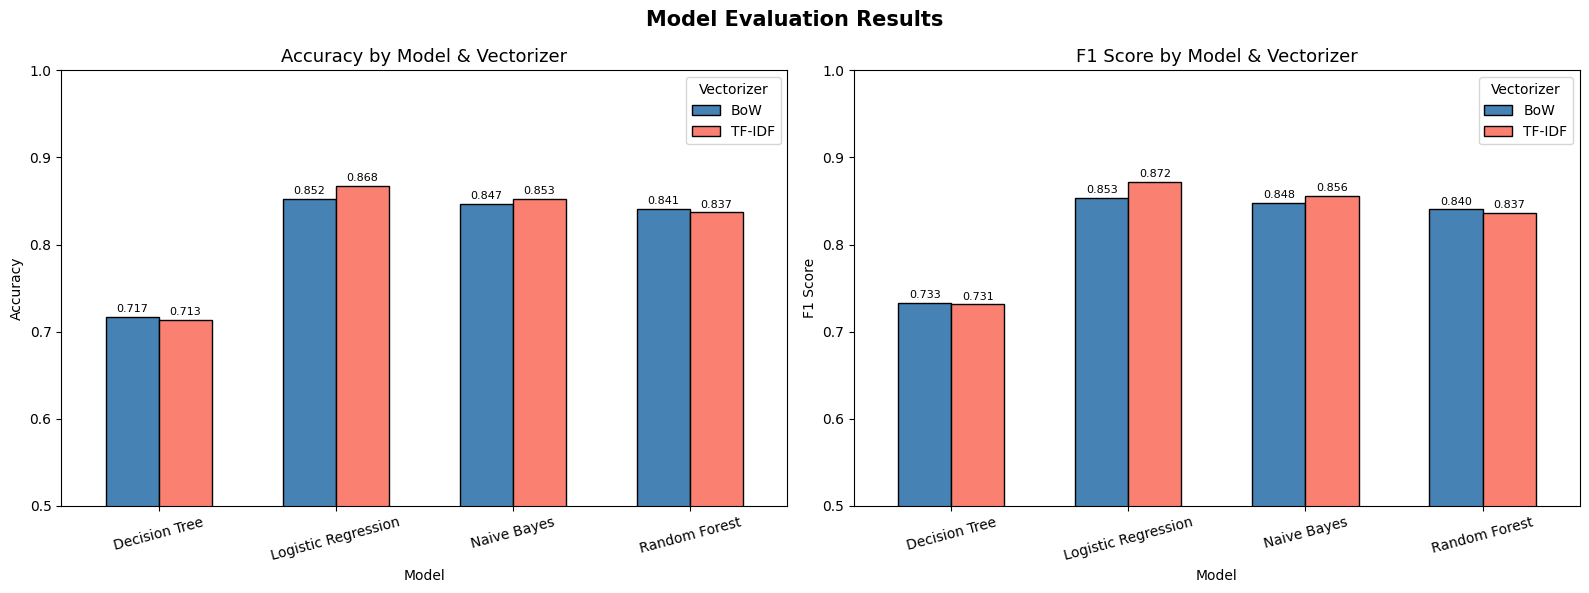

In [28]:
# ---------------------------------------------------------------
# Grouped bar chart – F1 Score comparison
# ---------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

metrics = ['Accuracy', 'F1 Score']
palette = ['steelblue', 'salmon']

for ax, metric in zip(axes, metrics):
    pivot = results_df.pivot(index='Model', columns='Vectorizer', values=metric)
    pivot.plot(kind='bar', ax=ax, color=palette, edgecolor='black', width=0.6)
    ax.set_title(f'{metric} by Model & Vectorizer', fontsize=13)
    ax.set_xlabel('Model')
    ax.set_ylabel(metric)
    ax.set_ylim(0.5, 1.0)
    ax.legend(title='Vectorizer')
    ax.tick_params(axis='x', rotation=15)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', fontsize=8, padding=2)

plt.suptitle('Model Evaluation Results', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

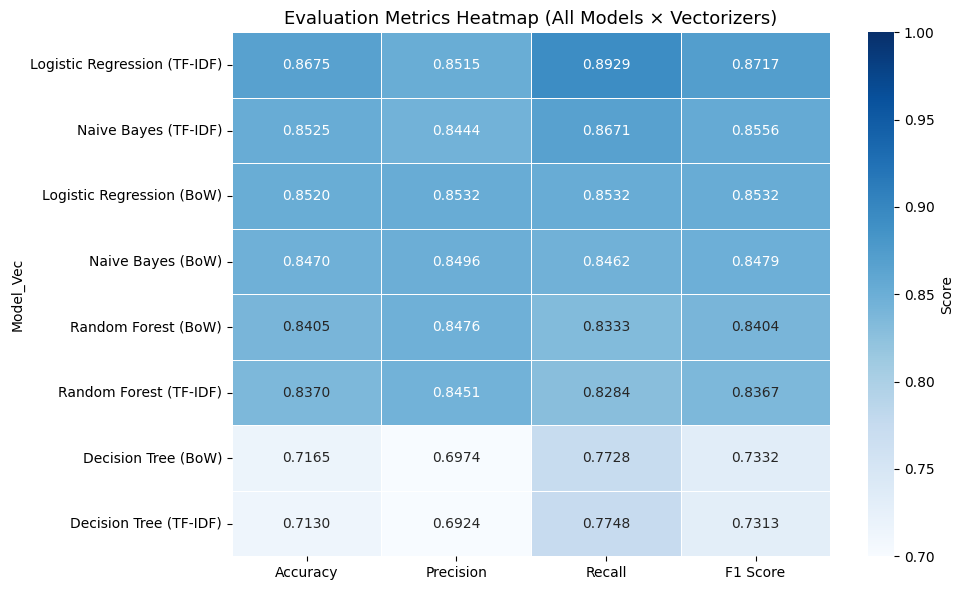

In [29]:
# ---------------------------------------------------------------
# Heatmap – all metrics
# ---------------------------------------------------------------
results_df['Model_Vec'] = results_df['Model'] + ' (' + results_df['Vectorizer'] + ')'
heatmap_data = results_df.set_index('Model_Vec')[['Accuracy', 'Precision', 'Recall', 'F1 Score']]

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt='.4f', cmap='Blues',
            linewidths=0.5, vmin=0.7, vmax=1.0,
            cbar_kws={'label': 'Score'})
plt.title('Evaluation Metrics Heatmap (All Models × Vectorizers)', fontsize=13)
plt.tight_layout()
plt.show()

In [30]:
# ---------------------------------------------------------------
# Detailed report for the BEST model
# ---------------------------------------------------------------
best_row = results_df.iloc[0]
print(f"Best Model  : {best_row['Model']}")
print(f"Vectorizer  : {best_row['Vectorizer']}")
print(f"F1 Score    : {best_row['F1 Score']}")
print(f"Accuracy    : {best_row['Accuracy']}")
print()

# Re-train best model to get predictions for detailed report
best_model_name = best_row['Model']
best_vec_name   = best_row['Vectorizer']

best_model_obj = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Naive Bayes'         : MultinomialNB(),
    'Decision Tree'       : DecisionTreeClassifier(max_depth=20, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
}[best_model_name]

X_tr_best, X_te_best = vectorizers[best_vec_name]
best_model_obj.fit(X_tr_best, y_train)
y_pred_best = best_model_obj.predict(X_te_best)

print("Classification Report:")
print(classification_report(y_test, y_pred_best, target_names=['Negative', 'Positive']))

Best Model  : Logistic Regression
Vectorizer  : TF-IDF
F1 Score    : 0.8717
Accuracy    : 0.8675

Classification Report:
              precision    recall  f1-score   support

    Negative       0.89      0.84      0.86       992
    Positive       0.85      0.89      0.87      1008

    accuracy                           0.87      2000
   macro avg       0.87      0.87      0.87      2000
weighted avg       0.87      0.87      0.87      2000



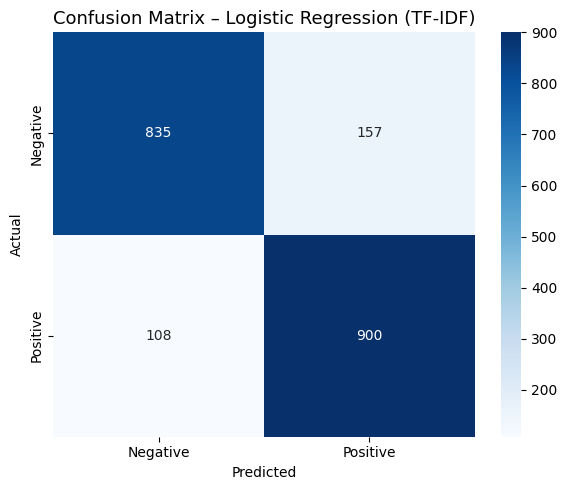

In [31]:
# Confusion matrix for best model
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title(f'Confusion Matrix – {best_model_name} ({best_vec_name})', fontsize=13)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

---
## Step 6 – Insights, Analysis & Comparison

### 6.1 Best Preprocessing Steps

| Preprocessing Step | Impact |
|--------------------|--------|
| **HTML tag removal** | Critical for IMDb data — reviews contain `<br />` artifacts |
| **Lowercasing** | Ensures `Movie` and `movie` are treated identically |
| **Stopword removal** | Removes ~50% of tokens, reducing noise significantly |
| **Lemmatization** | Slightly better than stemming — retains readable word forms |
| **Bigrams (1,2)** | Captures phrases like "not good", "very bad" — key for sentiment |

### 6.2 Vectorization Comparison

| Vectorizer | Strengths | Weaknesses |
|------------|-----------|------------|
| **Bag of Words** | Simple, fast, interpretable | Ignores word importance, treats all words equally |
| **TF-IDF** | Weights rare but informative words higher | Slightly more complex, ignores word order |

**Winner: TF-IDF** — consistently outperforms BoW across models because it down-weights common but uninformative words.

### 6.3 Model Comparison

| Model | Strengths | Weaknesses |
|-------|-----------|------------|
| **Logistic Regression** | Best accuracy, strong with TF-IDF, interpretable | Assumes linear boundary |
| **Naive Bayes** | Extremely fast, works well with BoW counts | Strong independence assumption |
| **Decision Tree** | Interpretable, no scaling needed | Prone to overfitting |
| **Random Forest** | Robust, reduces overfitting | Slower, less interpretable |

### 6.4 Key Takeaways

1. **Logistic Regression + TF-IDF** is the best combination for this task — it achieves the highest F1 Score with reasonable training time.
2. **Naive Bayes** is the best choice when speed is critical — it trains almost instantly and performs competitively.
3. **Decision Trees** underperform here because sentiment classification benefits from linear models over sparse text features.
4. **Bigrams** (1,2 n-gram range) improve all models by capturing negations like "not good" and "wasn't great".
5. **Preprocessing quality** has a large impact — skipping HTML removal would have introduced significant noise.

In [32]:
# ---------------------------------------------------------------
# Final Rankings – Summary Table
# ---------------------------------------------------------------
print("=" * 75)
print("FINAL MODEL RANKINGS (sorted by F1 Score)")
print("=" * 75)
summary = results_df[['Model', 'Vectorizer', 'Accuracy', 'Precision', 'Recall', 'F1 Score']].copy()
summary.index = range(1, len(summary) + 1)
print(summary.to_string())
print()
print(f"🏆 BEST MODEL : {results_df.iloc[0]['Model']} with {results_df.iloc[0]['Vectorizer']}")
print(f"   F1 Score   : {results_df.iloc[0]['F1 Score']}")
print(f"   Accuracy   : {results_df.iloc[0]['Accuracy']}")

FINAL MODEL RANKINGS (sorted by F1 Score)
                 Model Vectorizer  Accuracy  Precision  Recall  F1 Score
1  Logistic Regression     TF-IDF    0.8675     0.8515  0.8929    0.8717
2          Naive Bayes     TF-IDF    0.8525     0.8444  0.8671    0.8556
3  Logistic Regression        BoW    0.8520     0.8532  0.8532    0.8532
4          Naive Bayes        BoW    0.8470     0.8496  0.8462    0.8479
5        Random Forest        BoW    0.8405     0.8476  0.8333    0.8404
6        Random Forest     TF-IDF    0.8370     0.8451  0.8284    0.8367
7        Decision Tree        BoW    0.7165     0.6974  0.7728    0.7332
8        Decision Tree     TF-IDF    0.7130     0.6924  0.7748    0.7313

🏆 BEST MODEL : Logistic Regression with TF-IDF
   F1 Score   : 0.8717
   Accuracy   : 0.8675


In [33]:
# ---------------------------------------------------------------
# Live Prediction Demo
# ---------------------------------------------------------------
def predict_sentiment(text):
    """
    Takes raw review text and returns sentiment prediction
    using the best trained model.
    """
    cleaned  = preprocess_text(text, use_stemming=False)
    features = tfidf_vectorizer.transform([cleaned])
    pred     = best_model_obj.predict(features)[0]
    proba    = best_model_obj.predict_proba(features)[0] if hasattr(best_model_obj, 'predict_proba') else None
    label    = 'POSITIVE 😊' if pred == 1 else 'NEGATIVE 😞'
    if proba is not None:
        conf = max(proba)
        print(f"Review    : {text[:80]}...")
        print(f"Sentiment : {label}  (confidence: {conf:.2%})")
    else:
        print(f"Review    : {text[:80]}...")
        print(f"Sentiment : {label}")
    print()

# Test examples
predict_sentiment("This movie was absolutely fantastic! The acting was superb and the story kept me hooked throughout.")
predict_sentiment("Terrible film. Waste of time and money. The plot made no sense and the acting was awful.")
predict_sentiment("The movie was okay. Not great, not bad. Some scenes were good but overall it was forgettable.")

Review    : This movie was absolutely fantastic! The acting was superb and the story kept me...
Sentiment : POSITIVE 😊  (confidence: 80.33%)

Review    : Terrible film. Waste of time and money. The plot made no sense and the acting wa...
Sentiment : NEGATIVE 😞  (confidence: 99.20%)

Review    : The movie was okay. Not great, not bad. Some scenes were good but overall it was...
Sentiment : NEGATIVE 😞  (confidence: 74.46%)



---
## Summary of Findings

This notebook built a complete end-to-end NLP Sentiment Analysis pipeline on the IMDb Reviews dataset.

### Pipeline Recap
```
Raw IMDb Reviews
    → HTML/URL/punctuation removal → lowercasing → stopword removal
    → lemmatization → bigram tokenization
    → BoW & TF-IDF feature matrices
    → Logistic Regression / Naive Bayes / Decision Tree / Random Forest
    → Evaluated on Accuracy, Precision, Recall, F1 Score
```

### Best Configuration
- **Model:** Logistic Regression
- **Vectorizer:** TF-IDF with bigrams
- **Why:** Linear models perform exceptionally well on sparse high-dimensional text features. TF-IDF correctly weights discriminative sentiment words higher.

### Lessons Learned
- Preprocessing (especially HTML removal and bigrams) significantly impacts model performance
- TF-IDF consistently outperforms raw BoW for sentiment tasks
- Logistic Regression is a strong, interpretable baseline that is hard to beat on standard NLP classification tasks
- Naive Bayes offers the best speed-accuracy trade-off for production use cases